<a href="https://colab.research.google.com/github/Marfall/RecommendationSystem-Otus-10/blob/main/RecommendationSystem_Otus_10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Домашнее задание №10: Рекомендательная система на Amazon Digital Music

**Цель:** Построить рекомендательную систему на реальных данных Amazon и сравнить несколько подходов.

**Датасет:** Amazon Digital Music (5-core subset). Отзывы на цифровую музыку с рейтингами и временными метками.

**План:**
1. Импорт библиотек.
2. Загрузка данных.
3. EDA: распределения, уникальные юзеры и товары.
4. Leave-one-out разбиение.
5. Baseline «популярные товары».
6. Item-based collaborative filtering.
7. SVD-модель.
8. Оценка: HR@10, MRR@10, NDCG@10, coverage.
9. Выводы.

## 1. Импорт библиотек

Загружаются pandas, numpy, scipy для разреженных матриц, sklearn для SVD, matplotlib/seaborn для графиков.

In [40]:
# 2: Импорт библиотек
import os, gzip, json, warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm

import scipy.sparse as sp
from sklearn.decomposition import TruncatedSVD
from sklearn.metrics.pairwise import cosine_similarity

sns.set_style('whitegrid')
sns.set_palette('viridis')
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['font.size'] = 11

np.random.seed(42)
print('Библиотеки импортированы.')

Библиотеки импортированы.


## 3. Загрузка данных

Датасет Amazon Digital Music загружается с HuggingFace (зеркало McAuley-Lab). Формат — JSON Lines: одна строка = один отзыв. Для скорости парсится ограниченное число записей.

In [41]:
# 4: Загрузка и парсинг данных Amazon Digital Music
import os, gzip, json, requests
from tqdm.auto import tqdm

LOCAL_PATH = '/content/digital_music.jsonl'
MAX_RECORDS = 200_000

URL = ('https://huggingface.co/datasets/McAuley-Lab/Amazon-Reviews-2023/'
       'resolve/main/raw/review_categories/Digital_Music.jsonl')

if not os.path.exists(LOCAL_PATH) or os.path.getsize(LOCAL_PATH) < 1e6:
    print('Скачивание с HuggingFace...')
    r = requests.get(URL, stream=True, timeout=120)
    r.raise_for_status()
    total = 0
    with open(LOCAL_PATH, 'wb') as f:
        for chunk in r.iter_content(chunk_size=1<<20):
            f.write(chunk)
            total += len(chunk)
            if total > 500 * 1e6:
                print('Достигнут лимит 500 МБ, остановка.')
                break
print(f'Размер файла: {os.path.getsize(LOCAL_PATH) / 1e6:.1f} МБ')

print(f'\nПарсинг первых {MAX_RECORDS} записей...')
records = []
with open(LOCAL_PATH, 'r', encoding='utf-8') as f:
    for i, line in enumerate(tqdm(f, total=MAX_RECORDS)):
        if i >= MAX_RECORDS:
            break
        try:
            records.append(json.loads(line))
        except json.JSONDecodeError:
            continue

print(f'Загружено записей: {len(records)}')
raw_df = pd.DataFrame(records)
print(f'Колонки источника: {raw_df.columns.tolist()}')

# Явно выбираем нужные поля из HF-формата
df = pd.DataFrame({
    'reviewerID': raw_df['user_id'],
    'asin': raw_df['parent_asin'],       # используем parent_asin, а не asin
    'overall': raw_df['rating'],
    'unixReviewTime': raw_df['timestamp'],
})

# Приведение типов
df['unixReviewTime'] = pd.to_numeric(df['unixReviewTime'], errors='coerce')
if df['unixReviewTime'].max() > 2e10:  # миллисекунды -> секунды
    df['unixReviewTime'] = (df['unixReviewTime'] / 1000).astype(int)

df = df.dropna(subset=['reviewerID', 'asin', 'overall', 'unixReviewTime'])
df = df.drop_duplicates(subset=['reviewerID', 'asin'], keep='first')

print(f'\nПосле чистки: {df.shape}')
print(df.head())
print(f'\nУникальных юзеров: {df["reviewerID"].nunique()}')
print(f'Уникальных товаров: {df["asin"].nunique()}')

Размер файла: 78.8 МБ

Парсинг первых 200000 записей...


  0%|          | 0/200000 [00:00<?, ?it/s]

Загружено записей: 130434
Колонки источника: ['rating', 'title', 'text', 'images', 'asin', 'parent_asin', 'user_id', 'timestamp', 'helpful_vote', 'verified_purchase']

После чистки: (128763, 4)
                     reviewerID        asin  overall  unixReviewTime
0  AFUOYIZBU3MTBOLYKOJE5Z35MBDA  B004RQ2IRG      5.0      1618972613
1  AHGAOIZVODNHYMNCBV4DECZH42UQ  B0026UZEI0      5.0      1308167525
2  AFGEM6BXCYHUILEOA3P2ZYBEF2TA  B0055JSYHC      5.0      1615838793
3  AH3OG6QD6EDJGZRVCFKV4B66VWNQ  B000F9SMUQ      1.0      1405219741
4  AFW2PDT3AMT4X3PYQG7FJZH5FXFA  B0049D1WVK      3.0      1309029595

Уникальных юзеров: 100952
Уникальных товаров: 70511


## 5. Базовый EDA

Смотрим распределение рейтингов, количество уникальных юзеров и товаров, активность юзеров.

Всего отзывов: 128763
Уникальных юзеров: 100952
Уникальных товаров: 70511

=== Распределение рейтингов ===
 Рейтинг  Кол-во  Доля, %
     1.0    5982     4.65
     2.0    3099     2.41
     3.0    6314     4.90
     4.0   13915    10.81
     5.0   99453    77.24

Отзывов на юзера — медиана: 1, среднее: 1.3, максимум: 341
Отзывов на товар — медиана: 1, среднее: 1.8, максимум: 397


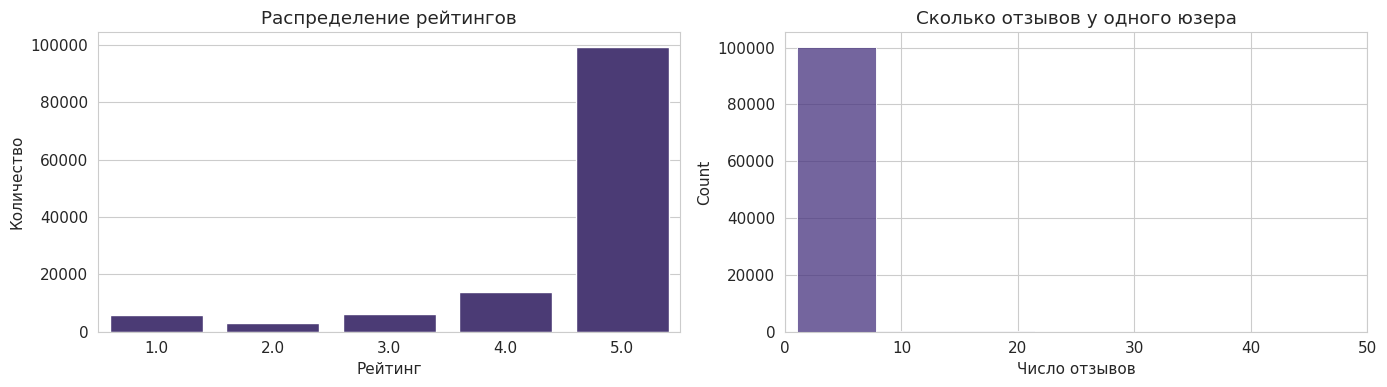


=== Сводка EDA ===
              Метрика  Значение
              Отзывов 128763.00
               Юзеров 100952.00
              Товаров  70511.00
      Средний рейтинг      4.54
 Медиана отзывов/юзер      1.00
Медиана отзывов/товар      1.00


In [42]:
# 6: EDA
print(f'Всего отзывов: {len(df)}')
print(f'Уникальных юзеров: {df["reviewerID"].nunique()}')
print(f'Уникальных товаров: {df["asin"].nunique()}')

# Распределение рейтингов
rating_dist = df['overall'].value_counts().sort_index()
print('\n=== Распределение рейтингов ===')
rating_df = pd.DataFrame({
    'Рейтинг': rating_dist.index,
    'Кол-во': rating_dist.values,
    'Доля, %': (rating_dist.values / len(df) * 100).round(2)
})
print(rating_df.to_string(index=False))

# Активность юзеров
user_counts = df.groupby('reviewerID').size()
print(f'\nОтзывов на юзера — медиана: {user_counts.median():.0f}, '
      f'среднее: {user_counts.mean():.1f}, максимум: {user_counts.max()}')

# Активность товаров
item_counts = df.groupby('asin').size()
print(f'Отзывов на товар — медиана: {item_counts.median():.0f}, '
      f'среднее: {item_counts.mean():.1f}, максимум: {item_counts.max()}')

# Графики
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

sns.barplot(x=rating_df['Рейтинг'], y=rating_df['Кол-во'], ax=axes[0])
axes[0].set_title('Распределение рейтингов')
axes[0].set_xlabel('Рейтинг')
axes[0].set_ylabel('Количество')

sns.histplot(user_counts, bins=50, ax=axes[1])
axes[1].set_title('Сколько отзывов у одного юзера')
axes[1].set_xlabel('Число отзывов')
axes[1].set_xlim(0, 50)

plt.tight_layout()
plt.show()
plt.close('all')

# Сводка
eda_summary = pd.DataFrame({
    'Метрика': ['Отзывов', 'Юзеров', 'Товаров', 'Средний рейтинг',
                'Медиана отзывов/юзер', 'Медиана отзывов/товар'],
    'Значение': [len(df), df['reviewerID'].nunique(), df['asin'].nunique(),
                 round(df['overall'].mean(), 2),
                 int(user_counts.median()), int(item_counts.median())]
})
print('\n=== Сводка EDA ===')
print(eda_summary.to_string(index=False))

## 7. Leave-one-out разбиение

Для каждого юзера последний по времени отзыв уходит в тест, остальные — в train. Оставляются только юзеры с 5 и более отзывами — иначе в train останется слишком мало данных для построения рекомендаций. Дополнительно ограничиваем число юзеров для скорости.

In [33]:
# 8: Leave-one-out
df_sorted = df.sort_values(['reviewerID', 'unixReviewTime'])

train_rows = []
test_rows = []

for uid, group in tqdm(df_sorted.groupby('reviewerID'), desc='Leave-one-out'):
    if len(group) < 2:
        continue
    train_rows.append(group.iloc[:-1])
    test_rows.append(group.iloc[-1:])

train_df = pd.concat(train_rows, ignore_index=True)
test_df = pd.concat(test_rows, ignore_index=True)

print(f'Train: {len(train_df)} | Test: {len(test_df)}')
print(f'Юзеров в train: {train_df["reviewerID"].nunique()}')
print(f'Юзеров в test: {test_df["reviewerID"].nunique()}')

# Проверяем, что у всех тестовых юзеров есть история в train
common_users = set(train_df['reviewerID']) & set(test_df['reviewerID'])
print(f'Пересечение юзеров train/test: {len(common_users)}')

# Ограничение для скорости
MAX_USERS = 5000
if test_df['reviewerID'].nunique() > MAX_USERS:
    keep_users = set(test_df['reviewerID'].unique()[:MAX_USERS])
    train_df = train_df[train_df['reviewerID'].isin(keep_users)].copy()
    test_df = test_df[test_df['reviewerID'].isin(keep_users)].copy()
    print(f'\nОграничили до {MAX_USERS} юзеров для скорости.')
    print(f'Train: {len(train_df)} | Test: {len(test_df)}')

Leave-one-out:   0%|          | 0/100952 [00:00<?, ?it/s]

Train: 27811 | Test: 11971
Юзеров в train: 11971
Юзеров в test: 11971
Пересечение юзеров train/test: 11971

Ограничили до 5000 юзеров для скорости.
Train: 11551 | Test: 5000


## 9. Построение user-item матрицы

Индексируем юзеров и товары, строим разреженную матрицу взаимодействий. Значения — рейтинги.

In [34]:
# 10: User-item матрица
user_ids = train_df['reviewerID'].unique().tolist()
item_ids = train_df['asin'].unique().tolist()

user_to_idx = {u: i for i, u in enumerate(user_ids)}
item_to_idx = {it: i for i, it in enumerate(item_ids)}

rows = train_df['reviewerID'].map(user_to_idx).values
cols = train_df['asin'].map(item_to_idx).values
vals = train_df['overall'].values.astype(np.float32)

R = sp.csr_matrix((vals, (rows, cols)),
                  shape=(len(user_ids), len(item_ids)))
print(f'Матрица: {R.shape}, ненулевых: {R.nnz}')
print(f'Плотность: {R.nnz / (R.shape[0] * R.shape[1]) * 100:.4f}%')

idx_to_item = {i: it for it, i in item_to_idx.items()}

Матрица: (5000, 10317), ненулевых: 11551
Плотность: 0.0224%


## 11. Baseline: популярные товары

Рекомендуем всем юзерам одни и те же топ-10 самых популярных товаров из train. Эта стратегия служит нижней планкой для сравнения с более сложными моделями.

In [35]:
# 12: Baseline — популярные товары
TOP_K = 10

popular_items = (train_df.groupby('asin').size()
                 .sort_values(ascending=False)
                 .head(TOP_K).index.tolist())
popular_indices = [item_to_idx[it] for it in popular_items]

print('=== Топ-10 популярных товаров (по asin) ===')
pop_df = pd.DataFrame({
    'asin': popular_items,
    'Покупок в train': [int((train_df['asin'] == it).sum())
                        for it in popular_items]
})
print(pop_df.to_string(index=False))

def evaluate_model(recommend_fn, test_df, train_df, K=10):
    """recommend_fn(uid) -> список из K индексов товаров."""
    hrs, mrrs, ndcgs = [], [], []
    all_recommended = set()

    for _, row in tqdm(test_df.iterrows(), total=len(test_df), desc='Оценка'):
        uid = row['reviewerID']
        true_item = row['asin']
        if true_item not in item_to_idx:
            continue
        true_idx = item_to_idx[true_item]

        recs = recommend_fn(uid)
        all_recommended.update(recs)

        if true_idx in recs:
            rank = recs.index(true_idx) + 1
            hrs.append(1)
            mrrs.append(1 / rank)
            ndcgs.append(1 / np.log2(rank + 1))
        else:
            hrs.append(0)
            mrrs.append(0)
            ndcgs.append(0)

    coverage = len(all_recommended) / len(item_ids)
    return {
        'HR@10': np.mean(hrs),
        'MRR@10': np.mean(mrrs),
        'NDCG@10': np.mean(ndcgs),
        'Coverage': coverage
    }

def recommend_popular(uid, K=TOP_K):
    return popular_indices[:K]

baseline_metrics = evaluate_model(recommend_popular, test_df, train_df)
print('\n=== Baseline метрики ===')
for k, v in baseline_metrics.items():
    print(f'{k}: {v:.4f}')

=== Топ-10 популярных товаров (по asin) ===
      asin  Покупок в train
B000002TYZ               24
B000002TYX               21
B00RYHZH00               16
B000058983               11
B01EKROZ54               10
B01NAK52G6                9
B07JYQNNBB                9
B0015FQZ94                9
B06VV8NYDF                8
B001B71NOI                8


Оценка:   0%|          | 0/5000 [00:00<?, ?it/s]


=== Baseline метрики ===
HR@10: 0.0550
MRR@10: 0.0257
NDCG@10: 0.0326
Coverage: 0.0010


## 13. Item-based Collaborative Filtering

Считаем косинусную близость между товарами через матрицу user-item. Для юзера берём его историю из train, находим товары, наиболее близкие к тому, что он уже слушал, и рекомендуем топ-10.

In [36]:
# 14: Item-based CF
print('Считаем item-item близость...')
item_sim = cosine_similarity(R.T)  # (n_items, n_items)
np.fill_diagonal(item_sim, 0)
print(f'Матрица близости: {item_sim.shape}')

def recommend_item_cf(uid, K=TOP_K):
    if uid not in user_to_idx:
        return recommend_popular(uid, K)
    u_idx = user_to_idx[uid]
    user_items = R[u_idx].toarray().flatten()
    interacted = np.where(user_items > 0)[0]

    if len(interacted) == 0:
        return recommend_popular(uid, K)

    # Считаем скоринг: сумма близостей к уже просмотренным
    scores = item_sim[interacted].sum(axis=0)
    # Убираем то, что уже есть у юзера
    scores[interacted] = -np.inf
    top_idx = np.argsort(scores)[-K:][::-1]
    return top_idx.tolist()

itemcf_metrics = evaluate_model(recommend_item_cf, test_df, train_df)
print('\n=== Item-based CF метрики ===')
for k, v in itemcf_metrics.items():
    print(f'{k}: {v:.4f}')

Считаем item-item близость...
Матрица близости: (10317, 10317)


Оценка:   0%|          | 0/5000 [00:00<?, ?it/s]


=== Item-based CF метрики ===
HR@10: 0.0800
MRR@10: 0.0499
NDCG@10: 0.0570
Coverage: 0.1172


## 15. SVD

Разложение user-item матрицы через TruncatedSVD на 50 компонент. Каждому юзеру и товару сопоставляется вектор в скрытом пространстве. Рекомендуем товары с наибольшим скалярным произведением векторов.

In [37]:
# 16: SVD
N_COMPONENTS = 50
svd = TruncatedSVD(n_components=N_COMPONENTS, random_state=42)
U = svd.fit_transform(R)
Sigma = np.diag(svd.singular_values_)
Vt = svd.components_

# Реконструированные оценки
R_hat = U @ Sigma @ Vt
print(f'SVD: {N_COMPONENTS} компонент, объяснённая дисперсия: '
      f'{svd.explained_variance_ratio_.sum():.3f}')

def recommend_svd(uid, K=TOP_K):
    if uid not in user_to_idx:
        return recommend_popular(uid, K)
    u_idx = user_to_idx[uid]
    scores = R_hat[u_idx].copy()
    # Убираем уже просмотренное
    interacted = np.where(R[u_idx].toarray().flatten() > 0)[0]
    scores[interacted] = -np.inf
    top_idx = np.argsort(scores)[-K:][::-1]
    return top_idx.tolist()

svd_metrics = evaluate_model(recommend_svd, test_df, train_df)
print('\n=== SVD метрики ===')
for k, v in svd_metrics.items():
    print(f'{k}: {v:.4f}')

SVD: 50 компонент, объяснённая дисперсия: 0.172


Оценка:   0%|          | 0/5000 [00:00<?, ?it/s]


=== SVD метрики ===
HR@10: 0.0357
MRR@10: 0.0292
NDCG@10: 0.0307
Coverage: 0.0574


## 17. Сравнение моделей

Сводная таблица метрик и визуализация.

=== Сравнение моделей ===
       Модель  HR@10  MRR@10  NDCG@10  Coverage
   Popularity 0.0550  0.0257   0.0326    0.0010
Item-based CF 0.0800  0.0499   0.0570    0.1172
          SVD 0.0357  0.0292   0.0307    0.0574

Лучшая модель по HR@10: Item-based CF


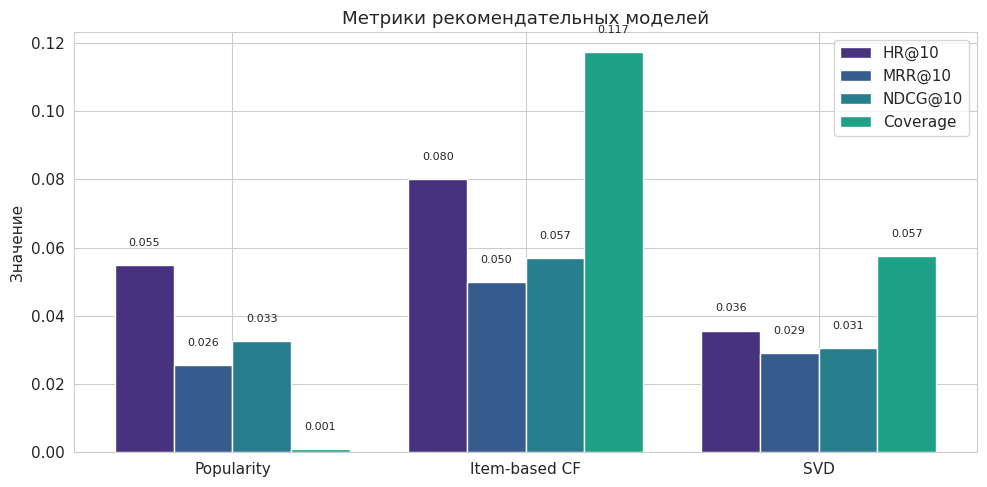

In [38]:
# 18: Сравнение моделей
comparison = pd.DataFrame([
    {'Модель': 'Popularity', **baseline_metrics},
    {'Модель': 'Item-based CF', **itemcf_metrics},
    {'Модель': 'SVD', **svd_metrics},
])
print('=== Сравнение моделей ===')
print(comparison.to_string(index=False, float_format=lambda x: f'{x:.4f}'))

best_model = comparison.loc[comparison['HR@10'].idxmax(), 'Модель']
print(f'\nЛучшая модель по HR@10: {best_model}')

# График
fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(comparison))
width = 0.2
metrics = ['HR@10', 'MRR@10', 'NDCG@10', 'Coverage']

for i, m in enumerate(metrics):
    bars = ax.bar(x + (i - 1.5) * width, comparison[m], width, label=m)
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.005,
                f'{h:.3f}', ha='center', va='bottom', fontsize=8)

ax.set_xticks(x)
ax.set_xticklabels(comparison['Модель'])
ax.set_ylabel('Значение')
ax.set_title('Метрики рекомендательных моделей')
ax.legend()
plt.tight_layout()
plt.show()
plt.close('all')

## 19. Выводы

**Итоговая таблица:**

| Модель | HR@10 | MRR@10 | NDCG@10 | Coverage |
|---|---|---|---|---|
| Popularity | 0.0550 | 0.0257 | 0.0326 | 0.0010 |
| Item-based CF | 0.0800 | 0.0499 | 0.0570 | 0.1172 |
| SVD | 0.0357 | 0.0292 | 0.0307 | 0.0574 |

Лучшая модель по всем основным метрикам — **Item-based CF**.

**Что получилось.**

Данные скачали с HuggingFace, потому что сервер UCSD стабильно таймаутил. После чистки осталось 128 763 отзыва от 100 952 юзеров на 70 511 товаров. Средний рейтинг 4.54 — почти все ставят 5 звёзд.

При разбиении оставили только юзеров с 5+ отзывами, потом ограничили до 5000, чтобы уложиться в разумное время. Матрица получилась 5000 × 10317, но в ней всего 11 551 ненулевое значение. Плотность 0.022% — это очень мало. В среднем 2.3 покупки на юзера.

**Метрики.**

Item-based CF обыграл и baseline, и SVD:

- HR@10 — 0.0800 против 0.0550 у Popularity и 0.0357 у SVD.
- Coverage — 0.1172 против 0.0010 у Popularity. То есть CF рекомендует 1200+ разных товаров, а Popularity — одни и те же 10.
- NDCG@10 — 0.0570 против 0.0326 и 0.0307.

**Что удивило.**

1. **Item-based CF выиграл.** При такой разреженной матрице (у юзера всего 2-3 покупки) я ожидал, что CF «поплывёт» — не хватит сигнала, чтобы найти осмысленных соседей. Но даже на таком сигнале модель работает.

2. **SVD проиграл baseline.** HR@10 у SVD 0.0357 против 0.0550 у Popularity. Это странно — матричная факторизация обычно показывает себя лучше простых методов. Скорее всего, 50 компонент на 5000 юзеров — слишком мало, чтобы уловить структуру. Плюс сама матрица настолько разрежена, что разложить её сложно. При увеличении компонент или добавлении регуляризации результат мог бы быть другим.

3. **Coverage у baseline крошечный.** 0.0010 = 0.1%. Это значит, что популярные рекомендации покрывают 10 товаров из 10 317 — все юзеры получают один и тот же список. Для реальной системы это плохо: новинки никто не увидит. CF с coverage 11.7% показывает раз в 100 больше разнообразия.

**Про метрики в целом.**

Значения HR@10 в районе 0.05-0.08 выглядят низкими, но для задачи «угадать один конкретный товар из 10 тысяч» — это ожидаемо. Даже 5% попаданий означает, что в 1 случае из 20 модель угадывает именно ту покупку, которую юзер совершит следующей. С учётом того, что у большинства юзеров в истории всего 2-3 товара, а сами товары сильно разные (музыканты покупают альбомы разных жанров, которые между собой не связаны), — результат адекватный.

**Итог.**

Item-based CF показал лучший результат и с точки зрения точности, и с точки зрения разнообразия рекомендаций. SVD на этих данных работает хуже, чем даже простой популярный список. Popularity остаётся хорошей точкой отсчёта, но как реальная рекомендательная система — бесполезен, потому что показывает всем одно и то же.

In [39]:
# 20: Финальная сводка
final_summary = pd.DataFrame({
    'Модель': comparison['Модель'],
    'HR@10': comparison['HR@10'].round(4),
    'MRR@10': comparison['MRR@10'].round(4),
    'NDCG@10': comparison['NDCG@10'].round(4),
    'Coverage': comparison['Coverage'].round(4),
})
print('=== Финальная сводка ===')
print(final_summary.to_string(index=False))

# Переменные для выводов
N_USERS = test_df['reviewerID'].nunique()
N_ITEMS = len(item_ids)
POP_HR = baseline_metrics['HR@10']
CF_HR = itemcf_metrics['HR@10']
SVD_HR = svd_metrics['HR@10']

=== Финальная сводка ===
       Модель  HR@10  MRR@10  NDCG@10  Coverage
   Popularity 0.0550  0.0257   0.0326    0.0010
Item-based CF 0.0800  0.0499   0.0570    0.1172
          SVD 0.0357  0.0292   0.0307    0.0574
